### 5.3.8 装饰器参数：can_jump_to
这里就涉及到Node-style的四个hook函数可以接收额外参数 `can_jump_to` 。
钩子函数可以 `改变Agent正常的运行轨迹` 。比如：发现上下文窗口溢出，直接跳转至结尾，提前终止整个Agent。

`can_jump_to` 决定了钩子函数可以直接跳转至流程的哪些位置，可取值如下：
* end：跳转至Agent流程末尾，或第一个after_agent钩子，直接终止整个流程。
* tools：跳转至工具节点。
* model：跳转至模型节点，或第一个before_model钩子。

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.tools import tool
from pydantic import BaseModel, Field

load_dotenv(override=True, verbose=True, dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

custom_profile = {
    "max_input_tokens": 128_000
}

model = ChatOpenAI(
    model="gpt-6-luna",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_API_BASE"],
    #profile=custom_profile
)

In [2]:
from typing import Any

from langchain.agents import create_agent
from langchain.agents.middleware import before_model, after_model, AgentState
from langchain.messages import AIMessage, SystemMessage
from langchain.tools import tool
from langgraph.runtime import Runtime


@tool
def get_news() -> str:
    """获取当日新闻"""
    return f"美加墨世界杯今日开幕"


# 在模型（LLM）执行前触发。允许跳转到 "tools" 节点。
@before_model(can_jump_to=["tools"])
def force_tool_first(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：强行拦截并触发工具】
    如果用户输入包含 "direct tool"，则跳过本次大模型的思考/生成阶段，
    直接伪造一个大模型的 tool_calls 意图，强行把控制权移交给工具执行节点。
    """
    text = state["messages"][-1].content
    # 检查消息内容关键词，满足条件则强行干预流程
    if isinstance(text, str) and "direct tool" in text.lower():
        print("[MIDDLEWARE] before_model: jump_to='tools'")

        # 人工构造一个大模型的消息对象（AIMessage）
        # 欺骗系统，让系统误以为这是模型自己决定要调用的工具
        fake_tool_call = AIMessage(
            content="人工构造的消息",
            tool_calls=[
                {
                    "name": "get_news",
                    "args": {},
                    "id": "call_force_weather_001",
                }
            ],
        )

        # 返回更新后的状态：注入伪造的消息，并明确指定下一步跳转到 "tools" 节点
        return {
            "messages": [fake_tool_call],
            "jump_to": "tools",
        }
    # 如果不满足触发条件，返回 None，流程正常向下流转（继续让 LLM 思考）
    return None


# 在模型（LLM）执行生成之后触发。允许重新跳转回 "model" 节点。
@after_model(can_jump_to=["model"])
def retry_with_extra_instruction(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：反思/重试机制】
    如果大模型已经生成了回答，但发现用户最初的请求包含 "retry model"，
    则动态追加一条系统提示词（SystemMessage），强行让模型重新生成（重试）一次。
    """
    # 倒序遍历消息历史，找到最近的一次用户输入（human 消息）
    user_text = ""
    for msg in reversed(state["messages"]):
        if getattr(msg, "type", "") == "human":
            user_text = getattr(msg, "content", "")
            break

    # 检查用户输入是否包含触发重试的关键字
    if isinstance(user_text, str) and "retry model" in user_text.lower():
        # 【核心防御】：防止无限循环重跳（死循环）
        # 检查消息历史中是否已经注入过这条特殊的系统提示。如果有，说明已经重试过了，不再重复干预。
        # for 循环遍历messages，检查是否有 SystemMessage 包含 "你必须以【二次回答】开头" 的内容
        already_injected = any(
            isinstance(getattr(msg, "content", None), str)
            and "你必须以【二次回答】开头" in msg.content
            for msg in state["messages"]
        )
        if already_injected:
            return None # 已注入过，直接放行，结束重试流程

        print("[MIDDLEWARE] after_model: jump_to='model' with extra system instruction")

        # 返回更新后的状态：追加强力约束的系统消息，并将指针跳回 "model" 节点重新执行
        return {
            "messages": [
                SystemMessage("你必须以【二次回答】开头，并且只用一句话回答。")
            ],
            "jump_to": "model",
        }

    return None

# 在模型（LLM）执行前触发。允许直接跳转到 "end" 节点（强行终止）。
@before_model(can_jump_to=["end"])
def overflow_context_processor(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：安全卫士/异常拦截】
    模拟上下文窗口溢出（Token超限）或其他严重的系统阻断情况。
    一旦触发，直接熔断流程，拒绝让大模型继续处理，直接报错或返回兜底文案。
    """

    # 假装溢出,模拟检查最后一条消息是否包含 overflow 标识
    if "overflow" in state["messages"][-1].content:
        print("[MIDDLEWARE] before_model: jump_to='end' when contenxt window overflow")

        # 构造兜底的结束消息，并直接指定跳转到 "end" 终止 Agent 运行
        return {
            "messages": [
                AIMessage("上下文窗口溢出，终止")
            ],
            "jump_to": "end",
        }

agent = create_agent(
    model=model,
    tools=[get_news],
    middleware=[force_tool_first, retry_with_extra_instruction, overflow_context_processor],
)

def run_once(user_input: str):
    result = agent.invoke(
        {
            "messages": [
                {"role": "user", "content": user_input}
            ]
        }
    )

    for msg in result["messages"]:
        msg.pretty_print()

if __name__ == "__main__":
    # Case 1: 直接跳 tools
    # 预期表现：
    # 1. 触发 force_tool_first，打印 "[MIDDLEWARE] before_model: jump_to='tools'"
    # 2. 绕过 LLM 的首轮思考，直接调用 `get_news` 工具
    # 3. 工具返回结果后，LLM 总结工具结果并输出
    print('=' * 30, '-> Case 1 <-', '=' * 30)
    run_once("请帮我查今日新闻 direct tool")

    # Case 2: 输出后跳回 model
    # 预期表现：
    # 1. 正常进入 LLM 生成第 1 版回答
    # 2. 触发 retry_with_extra_instruction，打印 "[MIDDLEWARE] after_model: jump_to='model'..."
    # 3. 注入系统提示词后，LLM 被强行拉回并生成第 2 版回答
    # 4. 最终输出应带有“【二次回答】”前缀
    print('=' * 30, '-> Case 2 <-', '=' * 30)
    run_once("请随便介绍一下 LangChain retry model")

    # Case 3:
    # 预期表现：
    # 1. 触发 overflow_context_processor 中间件
    # 2. 直接打印终止信息并退出，LLM 根本不会接收到这个请求
    print('=' * 30, '-> Case 3 <-', '=' * 30)
    run_once("你好 overflow")

    # Case 4: 正常流程
    # 预期表现：
    # 1. 没有任何中间件被触发（不满足任何关键字）
    # 2. Agent 走正常的 OOTB（Out of the box）标准工作流：User -> Model -> Call Tool -> Model -> End
    print('=' * 30, '-> Case 4 <-', '=' * 30)
    run_once("今日新闻摘要？")

============================== -> Case 1 <- ==============================
[MIDDLEWARE] before_model: jump_to='tools'
================================ Human Message =================================

请帮我查今日新闻 direct tool
================================== Ai Message ==================================

人工构造的消息
Tool Calls:
  get_news (call_force_weather_001)
 Call ID: call_force_weather_001
  Args:
================================= Tool Message =================================
Name: get_news

美加墨世界杯今日开幕
================================== Ai Message ==================================

[{'type': 'text', 'text': '今日新闻：美加墨世界杯今日开幕。', 'annotations': [], 'id': 'msg_0a76be8f71da6551bcae0c5367879315'}]
============================== -> Case 2 <- ==============================
[MIDDLEWARE] after_model: jump_to='model' with extra system instruction
================================ Human Message =================================

请随便介绍一下 LangChain retry model
================================== Ai M

1. 我们提前判定需要调用工具，直接在before_model中跳转至工具节点，省去了一次模型调用
2. 通过约定的 retry model标记 ，在after_model之后再次跳转到模型节点，触发模型重复调用
3. 通过约定的 overflow标记 ，模拟上下文窗口溢出，在before_model中直接跳转至结尾，提前终
止流程
4. Case 4 是没有被干预的正常Agent流程，作为对照。

2. 基于类实现

和基于装饰器实现的关键区别在于：需要引入额外的装饰器 `@hook_config` 为 `can_jump_to` 传参。

In [3]:
from typing import Any

from langchain.agents import create_agent
from langchain.agents.middleware import hook_config, AgentState, AgentMiddleware
from langchain.messages import AIMessage, SystemMessage
from langchain.tools import tool
from langgraph.runtime import Runtime


@tool
def get_news() -> str:
    """获取当日新闻"""
    return f"美加墨世界杯今日开幕"


class MyMiddleware(AgentMiddleware):
    @hook_config(can_jump_to=["tools", "end"])
    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        text = state["messages"][-1].content
        # 假装溢出
        if "overflow" in text:
            print("[MIDDLEWARE] before_model: jump_to='end' when contenxt window overflow")
            return {
                "messages": [
                    AIMessage("上下文窗口溢出，终止")
                ],
                "jump_to": "end",
            }

        if isinstance(text, str) and "direct tool" in text.lower():
            print("[MIDDLEWARE] before_model: jump_to='tools'")

            fake_tool_call = AIMessage(
                content="人工构造的消息",
                tool_calls=[
                    {
                        "name": "get_news",
                        "args": {},
                        "id": "call_force_weather_001",
                    }
                ],
            )

            return {
                "messages": [fake_tool_call],
                "jump_to": "tools",
            }

        return None

    @hook_config(can_jump_to=["model"])
    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        user_text = ""
        for msg in reversed(state["messages"]):
            if getattr(msg, "type", "") == "human":
                user_text = getattr(msg, "content", "")
                break

        if isinstance(user_text, str) and "retry model" in user_text.lower():
            # 防止无限重跳：如果已经加过提示，就不再跳
            already_injected = any(
                isinstance(getattr(msg, "content", None), str)
                and "你必须以【二次回答】开头" in msg.content
                for msg in state["messages"]
            )
            if already_injected:
                return None

            print("[MIDDLEWARE] after_model: jump_to='model' with extra system instruction")

            return {
                "messages": [
                    SystemMessage("你必须以【二次回答】开头，并且只用一句话回答。")
                ],
                "jump_to": "model",
            }

        return None


agent = create_agent(
    model=model,
    tools=[get_news],
    middleware=[MyMiddleware()],
)


def run_once(user_input: str):
    result = agent.invoke(
        {
            "messages": [
                {"role": "user", "content": user_input}
            ]
        }
    )

    for msg in result["messages"]:
        msg.pretty_print()


if __name__ == "__main__":
    # Case 1: 直接跳 tools
    print('=' * 30, '-> Case 1 <-', '=' * 30)
    run_once("请帮我查今日新闻 direct tool")

    # Case 2: 输出后跳回 model
    print('=' * 30, '-> Case 2 <-', '=' * 30)
    run_once("请随便介绍一下 LangChain retry model")

    # Case 3:
    print('=' * 30, '-> Case 3 <-', '=' * 30)
    run_once("你好 overflow")

    # Case 4: 正常流程
    print('=' * 30, '-> Case 4 <-', '=' * 30)
    run_once("今日新闻摘要？")

============================== -> Case 1 <- ==============================
[MIDDLEWARE] before_model: jump_to='tools'
================================ Human Message =================================

请帮我查今日新闻 direct tool
================================== Ai Message ==================================

人工构造的消息
Tool Calls:
  get_news (call_force_weather_001)
 Call ID: call_force_weather_001
  Args:
================================= Tool Message =================================
Name: get_news

美加墨世界杯今日开幕
================================== Ai Message ==================================

[{'id': 'rs_0d93a471e371c73a006ac5ac95bea887d1af7e5aa30fe3fb07', 'summary': [], 'type': 'reasoning', 'encrypted_content': 'gAAAAABqxayWabDyNlDqQ3rOzfWAkEzpkOVsixgsdy19yRjhyTuqMvQEd_yCRKneKtgjc2nB2kBqw9G7HeScimmjueJmN_OKVVfsJMFDtw8gIlEDDK6yecPXNxs1aiv-myjS3U24C99FzohwTihKnfFcR_b7iKJTJNpXfZYtlKUxdH3C8xU6wW32q0R5FB-aSHXH5-wXmC7WIZUxb4EFowkO8xgyzi-7QEv6001N7MbqBtj4ZwOj3GiB7r7tZ8LlhZoqqhUi4u1D8LU03-Pn8_qj0_TmcsL

### 5.3.9 装饰器的其他参数：state_schema、tools、name

5.3.8 用到了装饰器的 `can_jump_to` 参数。四个 node-style 装饰器（`@before_agent`、`@before_model`、`@after_model`、`@after_agent`）的参数完全相同，源码中的签名是：

```python
before_model(func=None, *, state_schema=None, tools=None, can_jump_to=None, name=None)
```

| 参数 | 作用 | 不传时 | 重要程度 |
|---|---|---|---|
| `can_jump_to` | 声明这个 hook 可以跳到哪里（5.3.8） | 不能跳转（有个例外，见 5.3.10） | ⭐ |
| `state_schema` | 给 state 增加自定义字段 | 使用默认的 `AgentState` | ⭐ 最常用 |
| `tools` | 中间件自带的工具，会自动注册到 Agent | 没有工具 | 了解 |
| `name` | 中间件的名字，也就是节点名的前缀 | 使用函数名 | 了解 |

第一个参数 `func` 是被装饰的函数本身，它决定了装饰器什么时候要带括号，见本节第 4 点。

#### 1. state_schema：给 state 增加自定义字段

07 笔记 5.3.4 讲过：hook 返回 state 中不存在的键，会被直接丢弃。中间件如果要记录自己的数据（如计数器、标记），需要先扩展 state 的结构：

1. 定义一个继承 `AgentState` 的类，加上自定义字段。字段一般用 `NotRequired` 包起来，表示“一开始可以没有这个键”，读取时用 `state.get(键, 默认值)`。
2. 通过 `state_schema=` 交给装饰器。`create_agent` 会把所有中间件的 `state_schema` 合并成 Agent 的 state 结构。

合并之后，自定义字段和 `messages` 一样：hook 可以读写，调用 `invoke` 时可以传入，返回结果中也有它。

下面的例子改编自官方文档，正好和 5.3.8 的 `can_jump_to` 配合使用：`after_model` 在每次模型返回后把 `model_call_count` 加 1；`before_model` 发现次数达到上限，就跳到 end，不再调用模型。

本例调用 1 次模型：第 2 次 `invoke` 被拦截，不调用模型。

In [4]:
from typing import Any
from typing_extensions import NotRequired
from langchain.agents.middleware import AgentState, after_model, before_model
from langchain.messages import AIMessage, HumanMessage
from langgraph.runtime import Runtime


class CallCountState(AgentState):
    """在 AgentState 的基础上增加一个自定义字段"""
    model_call_count: NotRequired[int]   # NotRequired：一开始可以没有这个键


MAX_CALLS = 3


@before_model(state_schema=CallCountState, can_jump_to=["end"])
def check_call_limit(state: CallCountState, runtime: Runtime) -> dict[str, Any] | None:
    count = state.get("model_call_count", 0)          # 读取自定义字段，没有时按 0 算
    print(f"[check_call_limit] 已调用模型 {count} 次")
    if count >= MAX_CALLS:
        return {
            "messages": [AIMessage(f"模型调用次数已达上限（{MAX_CALLS} 次），本次不再调用模型。")],
            "jump_to": "end",
        }
    return None


@after_model(state_schema=CallCountState)
def increment_counter(state: CallCountState, runtime: Runtime) -> dict[str, Any] | None:
    return {"model_call_count": state.get("model_call_count", 0) + 1}   # 写入自定义字段


counter_agent = create_agent(model=model, middleware=[check_call_limit, increment_counter])

print("—— 第 1 次 invoke：没有传入 model_call_count ——")
result = counter_agent.invoke({"messages": [HumanMessage("用一句话介绍你自己")]})
print("回答:", result["messages"][-1].text)
print("model_call_count =", result["model_call_count"])

print("\n—— 第 2 次 invoke：传入 model_call_count=3 ——")
result = counter_agent.invoke({"messages": [HumanMessage("用一句话介绍你自己")], "model_call_count": 3})
print("回答:", result["messages"][-1].text)
print("model_call_count =", result["model_call_count"])

—— 第 1 次 invoke：没有传入 model_call_count ——
[check_call_limit] 已调用模型 0 次
回答: 我是 ChatGPT，能帮你解答问题、整理思路、撰写内容，也乐于陪你一起探索新想法。
model_call_count = 1

—— 第 2 次 invoke：传入 model_call_count=3 ——
[check_call_limit] 已调用模型 3 次
回答: 模型调用次数已达上限（3 次），本次不再调用模型。
model_call_count = 3


分析：

1. 第 1 次 `invoke` 没有传入 `model_call_count`，`check_call_limit` 读到 0，模型正常调用；`increment_counter` 把它写成 1，返回结果中多了 `model_call_count` 这个键。
2. 第 2 次 `invoke` 在输入中传入 `model_call_count=3`，`check_call_limit` 读到 3，达到上限，跳到 end，模型没有被调用。
3. 两个 hook 都写了 `state_schema=CallCountState`。其实只要有一个中间件声明，这个字段就会加入 Agent 的 state，其他 hook 也能读到；但每个用到它的 hook 都写上，代码更清楚，IDE 也能提示 `state` 中有这个字段。
4. 每次 `invoke` 都从输入的 state 开始，计数不会跨 `invoke` 累计。要累计，需要配合 checkpointer：06 笔记中 `ModelCallLimitMiddleware` 的 `thread_limit` 就是这样实现的。

#### 2. tools：中间件自带的工具

`tools=[...]` 中的工具跟着中间件走：`create_agent` 会把它们和 `create_agent(tools=[...])` 中的工具合在一起，模型能看到并调用它们，流程图中也会自动出现 `tools` 节点。

用途是把“工具 + 配套的 hook”打包成一个功能，使用者加上中间件就行，不用再单独传工具。内置的 `TodoListMiddleware` 就是这样自带 `write_todos` 工具的（01 笔记 1.4.7）。

下面的 `create_agent` 没有传 `tools` 参数，工具只来自中间件。本例调用 2 次模型：第 1 次决定调用工具，第 2 次根据工具结果回答。

In [5]:
from datetime import datetime


@tool
def get_current_time() -> str:
    """获取当前的日期和时间"""
    return datetime.now().strftime("%Y-%m-%d %H:%M")


@before_model(tools=[get_current_time])          # 工具跟着中间件走
def time_helper(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"[time_helper] 调用模型前，state 中有 {len(state['messages'])} 条消息")
    return None


def show(messages):
    """简洁地打印消息：AI 消息调用工具时打印工具名和参数，其他消息打印文本"""
    for msg in messages:
        if getattr(msg, "tool_calls", None):
            print(f"{type(msg).__name__}: 调用工具 {[(call['name'], call['args']) for call in msg.tool_calls]}")
        else:
            print(f"{type(msg).__name__}: {msg.text}")


time_agent = create_agent(model=model, middleware=[time_helper])    # 注意：没有传 tools 参数
print("节点:", list(time_agent.get_graph().nodes))

result = time_agent.invoke({"messages": [HumanMessage("现在几点了？")]})
show(result["messages"])

节点: ['__start__', 'model', 'tools', 'time_helper.before_model', '__end__']
[time_helper] 调用模型前，state 中有 1 条消息
[time_helper] 调用模型前，state 中有 3 条消息
HumanMessage: 现在几点了？
AIMessage: 调用工具 [('get_current_time', {})]
ToolMessage: 2026-10-06 20:15
AIMessage: 现在是 2026 年 10 月 6 日 20:15。


分析：

1. `create_agent` 没有传 `tools`，流程图中却有 `tools` 节点，模型也调用了 `get_current_time`：这个工具来自中间件的 `tools` 参数。
2. `time_helper` 打印了两次：模型被调用了两次，before_model 在每次调用模型之前都会执行（07 笔记 5.2）。第 2 次时 state 中有 3 条消息：用户的问题、模型发起的工具调用、工具返回的结果。

#### 3. name：中间件的名字

`name` 默认是函数名，会成为节点名的前缀（`名字.before_model`），流程图、LangSmith 追踪、流式输出的 `langgraph_node` 中显示的都是它。它有两个用途：

* 起一个好读的名字；
* 避免重名：同一个 Agent 中不能有两个同名的中间件（07 笔记 5.3.5）。

用同一个函数批量生成中间件时最容易重名。下面的 `make_keyword_guard` 根据关键词生成中间件，里面的函数名都是 `keyword_guard`（本例不调用模型）：

In [6]:
def make_keyword_guard(keyword: str, name: str | None = None):
    """生成一个“消息中出现关键词就打印提醒”的中间件"""
    @before_model(name=name)                          # name 为 None 时，使用函数名 keyword_guard
    def keyword_guard(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if keyword in state["messages"][-1].text:
            print(f"[提醒] 消息中出现了“{keyword}”")
        return None
    return keyword_guard


# 不指定 name：两个中间件都叫 keyword_guard
guard_a = make_keyword_guard("密码")
guard_b = make_keyword_guard("身份证")
print("不指定 name:", guard_a.name, guard_b.name)
try:
    create_agent(model=model, middleware=[guard_a, guard_b])
except AssertionError as e:
    print("create_agent 报错:", e)

# 指定 name：名字不同，可以放进同一个 Agent
guard_a = make_keyword_guard("密码", name="password_guard")
guard_b = make_keyword_guard("身份证", name="id_card_guard")
guard_agent = create_agent(model=model, middleware=[guard_a, guard_b])
print("\n指定 name 后的节点:", list(guard_agent.get_graph().nodes))

不指定 name: keyword_guard keyword_guard
create_agent 报错: Please remove duplicate middleware instances.

指定 name 后的节点: ['__start__', 'model', 'password_guard.before_model', 'id_card_guard.before_model', '__end__']


分析：不指定 `name` 时，两个中间件都叫 `keyword_guard`，`create_agent` 报错；用 `name` 区分后，两个节点分别是 `password_guard.before_model` 和 `id_card_guard.before_model`。类写法中对应的做法是重写 `name` 属性（07 笔记 5.3.6 的 `OrderMiddleware`）。

#### 4. 补充：为什么有时写 `@before_model`，有时写 `@before_model(...)`

装饰器的第一个参数 `func` 默认是 `None`。`before_model` 根据有没有收到函数，决定返回什么：

| 写法 | 实际执行 | 结果 |
|---|---|---|
| `@before_model` | `before_model(函数)`：`func` 收到了函数 | 直接返回中间件实例 |
| `@before_model(name="x")` | 先执行 `before_model(name="x")`：`func` 是 `None`，返回一个装饰器；再执行 `装饰器(函数)` | 返回中间件实例 |

所以只要传参数，就必须带括号；空括号 `@before_model()` 也可以。验证一下（本例不调用模型）：

In [7]:
from langchain.agents.middleware import AgentMiddleware


# ① 不带括号：before_model 直接收到函数，返回中间件实例
@before_model
def hook_a(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return None


# ② 带括号：先执行 before_model(name="hook_b")，此时 func 是 None，返回的是一个装饰器
decorator = before_model(name="hook_b")
print("before_model(name='hook_b') 返回:", decorator)


# 再用这个装饰器装饰函数，才得到中间件实例。效果等同于 @before_model(name="hook_b")
@decorator
def my_func(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return None


print("hook_a  是中间件实例吗:", isinstance(hook_a, AgentMiddleware), "| 名字:", hook_a.name)
print("my_func 是中间件实例吗:", isinstance(my_func, AgentMiddleware), "| 名字:", my_func.name)

before_model(name='hook_b') 返回: <function before_model.<locals>.decorator at 0x10a760d60>
hook_a  是中间件实例吗: True | 名字: hook_a
my_func 是中间件实例吗: True | 名字: hook_b


分析：`before_model(name="hook_b")` 返回的是一个函数，也就是真正的装饰器；用它装饰 `my_func` 之后，得到的才是中间件实例，名字是指定的 `hook_b`。

#### 5. 了解：wrap-style 装饰器的参数

| 装饰器 | 参数 |
|---|---|
| `@wrap_model_call`、`@wrap_tool_call` | `state_schema`、`tools`、`name`，没有 `can_jump_to` |
| `@dynamic_prompt` | 没有参数 |

wrap-style hook 包裹在 `model`、`tools` 节点内部执行，不是单独的节点，所以没有 `can_jump_to`：想跳过模型或工具，直接不调用 `handler` 就行。

### 5.3.10 类写法为什么用 hook_config

#### 1. 原因：类写法中没有地方传 can_jump_to

装饰器写法通过 `@before_model(...)` 告诉框架“这是 before_model hook”，参数顺便在这里传。类写法靠方法名 `before_model` 识别 hook，不经过 `@before_model`。装饰器的四个参数，在类写法中各有对应写法：

| 装饰器参数 | 描述的对象 | 类写法中的写法 |
|---|---|---|
| `state_schema=X` | 整个中间件 | 类属性 `state_schema = X` |
| `tools=[...]` | 整个中间件 | 类属性 `tools = [...]` |
| `name="..."` | 整个中间件 | 重写 `name` 属性（默认是类名） |
| `can_jump_to=[...]` | **某一个 hook** | 在这个方法上加 `@hook_config(can_jump_to=[...])` |

前三个描述的是整个中间件，写成类属性就行。`can_jump_to` 描述的是某一个 hook：5.3.8 的 `MyMiddleware` 中，`before_model` 要能跳到 `tools`、`end`，`after_model` 要能跳到 `model`，两者各不相同。所以它只能贴在对应的方法上，这就需要一个给方法用的装饰器。

#### 2. hook_config 做了什么：给函数贴一个标签

源码（`langchain/agents/middleware/types.py`，简化）：

```python
def hook_config(*, can_jump_to=None):
    def decorator(func):
        if can_jump_to is not None:
            func.__can_jump_to__ = can_jump_to   # 只在函数对象上记下这个列表
        return func                              # 返回的还是原函数，行为不变
    return decorator
```

`create_agent` 组装流程图时读取这个标签，为这个 hook 节点加上通往这些目标的条件边。它叫 hook_config（hook 配置），是因为设计上用来给单个 hook 加配置，目前唯一的配置项是 `can_jump_to`。

装饰器写法的 `can_jump_to` 参数，最后贴的也是同一个标签。验证一下（本例不调用模型）：

In [8]:
from langchain.agents.middleware import hook_config


# ① hook_config 返回的还是原函数，只是函数上多了一个属性
def some_hook(state, runtime):
    return None


returned = hook_config(can_jump_to=["model"])(some_hook)
print("返回的是原函数吗:", returned is some_hook)
print("some_hook.__can_jump_to__ =", some_hook.__can_jump_to__)

# ② 5.3.8 类写法的 MyMiddleware：两个方法各自带着自己的标签
print("MyMiddleware.before_model.__can_jump_to__ =", MyMiddleware.before_model.__can_jump_to__)
print("MyMiddleware.after_model.__can_jump_to__  =", MyMiddleware.after_model.__can_jump_to__)

# ③ 5.3.8 装饰器写法的 force_tool_first：can_jump_to 参数贴在了装饰器生成的 before_model 方法上（07 笔记 5.3.5）
print("type(force_tool_first).before_model.__can_jump_to__ =", type(force_tool_first).before_model.__can_jump_to__)

返回的是原函数吗: True
some_hook.__can_jump_to__ = ['model']
MyMiddleware.before_model.__can_jump_to__ = ['tools', 'end']
MyMiddleware.after_model.__can_jump_to__  = ['model']
type(force_tool_first).before_model.__can_jump_to__ = ['tools']


#### 3. 为什么必须提前声明：建图时修路，运行时选路

流程图的边在 `create_agent` 时就固定了，运行时 `jump_to` 只能在已有的边中选一条。对比同一个 before_model hook 声明和不声明 `can_jump_to` 时的流程图（本例不调用模型）：

guard_declared.before_model 的出边: [('__end__', '条件边'), ('model', '条件边')]


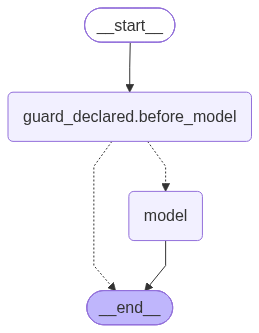

guard_undeclared.before_model 的出边: [('model', '普通边')]


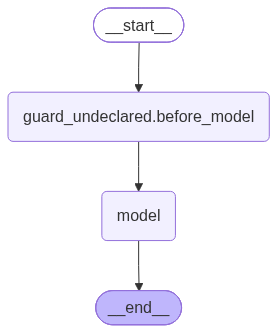

In [9]:
from IPython.display import Image, display


@before_model(can_jump_to=["end"])
def guard_declared(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return None


@before_model
def guard_undeclared(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return None


for mw in [guard_declared, guard_undeclared]:
    graph = create_agent(model=model, middleware=[mw]).get_graph()      # 只建图，不调用模型
    node = f"{mw.name}.before_model"
    edges = [(edge.target, "条件边" if edge.conditional else "普通边") for edge in graph.edges if edge.source == node]
    print(f"{node} 的出边: {edges}")
    display(Image(graph.draw_mermaid_png()))

分析：

* 声明了 `can_jump_to=["end"]`：`guard_declared.before_model` 有两条条件边（图中的虚线），通往 `model` 和 `__end__`。运行时根据 `jump_to` 选择走哪条，没有 `jump_to` 就走默认的 `model`。
* 没有声明：只有一条通往 `model` 的普通边（实线）。这时返回 `jump_to` 也没有路可走，只能继续去 `model`。

所以 `can_jump_to` 是建图时“修路”，`jump_to` 是运行时“选路”。

#### 4. 运行验证：几种写法对比

下面比较 4 种写法。每个 hook 都返回 `jump_to: "end"`，跳转生效时模型不会被调用。为了让每次输出一致，这里和 07 笔记 5.3.6 一样，使用 LangChain 自带的假模型 `GenericFakeChatModel`：它按顺序返回预先写好的消息，不调用任何接口。

In [10]:
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel


class FakeToolModel(GenericFakeChatModel):
    """假模型：按顺序返回预先写好的消息，不调用任何接口。"""

    def bind_tools(self, tools, **kwargs):
        return self  # create_agent 会调用 bind_tools，假模型直接返回自身


def stop():
    """hook 的返回值：追加一条消息，并跳到 end"""
    return {"messages": [AIMessage("拦截：不调用模型")], "jump_to": "end"}


# ① 用装饰器参数声明
@before_model(can_jump_to=["end"])
def stop_by_param(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return stop()


# ② 没有声明
@before_model
def stop_undeclared(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return stop()


# ③ 装饰器写法 + @hook_config，hook_config 紧贴着函数
@before_model
@hook_config(can_jump_to=["end"])
def stop_by_hook_config(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return stop()


# ④ 顺序写反：hook_config 写在 @before_model 上面
@hook_config(can_jump_to=["end"])
@before_model
def stop_wrong_order(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return stop()


for mw in [stop_by_param, stop_undeclared, stop_by_hook_config, stop_wrong_order]:
    fake_model = FakeToolModel(messages=iter([AIMessage("模型的回答")]))
    demo_agent = create_agent(model=fake_model, middleware=[mw])
    result = demo_agent.invoke({"messages": [HumanMessage("你好")]})
    print(f"{mw.name:<20} → {[msg.text for msg in result['messages']]}")

stop_by_param        → ['你好', '拦截：不调用模型']
stop_undeclared      → ['你好', '拦截：不调用模型', '模型的回答']
stop_by_hook_config  → ['你好', '拦截：不调用模型']
stop_wrong_order     → ['你好', '拦截：不调用模型', '模型的回答']


分析：

1. `stop_by_param` 和 `stop_by_hook_config` 都跳转成功，模型没有被调用。说明装饰器写法也能用 `@hook_config`（官方文档 Agent jumps 一节的装饰器例子就是这样写的），`@before_model(can_jump_to=...)` 只是更短的写法。
2. `stop_undeclared` 没有声明，`jump_to` 被忽略，不报错，模型照常被调用。
3. `stop_wrong_order` 把 `@hook_config` 写在了 `@before_model` 上面。装饰器从下往上执行，`@hook_config` 拿到的已经是生成好的中间件实例，标签贴在了实例上；而 `create_agent` 只读方法上的标签，所以跳转被忽略。`@hook_config` 必须紧贴着函数写。

另外，四个 node-style hook 都可以声明跳转，例如 `before_agent` 声明 `["end"]` 后，可以不调用模型直接结束。

#### 5. 两个容易困惑的现象

**现象 1：after_model 不声明也能跳转。** 5.3.8 的 `MyMiddleware` 中，去掉 `after_model` 上的 `@hook_config(can_jump_to=["model"])`，它仍然能跳回 model。原因是 Agent 有工具时，最后执行的那个 after_model 节点本来就要决定“去 tools、回 model 还是结束”，这几条边已经存在；没有工具时就没有这些边。用假模型验证：

In [11]:
from langchain.messages import SystemMessage


class RetryOnce(AgentMiddleware):
    """after_model 第一次执行时跳回 model。注意：没有用 hook_config 声明"""

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if not any(isinstance(msg, SystemMessage) for msg in state["messages"]):
            return {"messages": [SystemMessage("请重新回答")], "jump_to": "model"}
        return None


for tools in ([get_news], []):
    fake_model = FakeToolModel(messages=iter([AIMessage("模型第 1 次回答"), AIMessage("模型第 2 次回答")]))
    demo_agent = create_agent(model=fake_model, tools=tools, middleware=[RetryOnce()])
    edges = [edge.target for edge in demo_agent.get_graph().edges if edge.source == "RetryOnce.after_model"]
    result = demo_agent.invoke({"messages": [HumanMessage("你好")]})
    print(f"{'有' if tools else '没有'}工具：after_model 的出边 {edges}")
    print(f"    消息: {[msg.text for msg in result['messages']]}")

有工具：after_model 的出边 ['__end__', 'model', 'tools']
    消息: ['你好', '模型第 1 次回答', '请重新回答', '模型第 2 次回答']
没有工具：after_model 的出边 ['__end__']
    消息: ['你好', '模型第 1 次回答', '请重新回答']


分析：有工具时，`RetryOnce.after_model` 本来就有通往 `__end__`、`model`、`tools` 的边，没声明也跳回了 model，模型被调用了 2 次；没有工具时只有一条通往 `__end__` 的边，跳转被忽略。这是实现上的巧合，不要依赖，用到 `jump_to` 就声明。

**现象 2：声明的目标不存在时，create_agent 直接报错。** 声明了 `"tools"`，但 Agent 没有任何工具，流程图中就没有 `tools` 节点，建图时会报错（本例不调用模型）：

In [12]:
@before_model(can_jump_to=["tools"])
def jump_to_tools(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    return None


try:
    create_agent(model=model, middleware=[jump_to_tools])     # 没有传工具，中间件也没有自带工具
except ValueError as e:
    print("ValueError:", e)

ValueError: At 'jump_to_tools.before_model' node, 'jump_edge' branch found unknown target 'tools'


分析：报错发生在 `create_agent` 建图时，Agent 还没开始运行。

#### 6. 小结

| 问题 | 结论 |
|---|---|
| 类写法为什么用 `@hook_config` | 类写法不经过 `@before_model(...)`，而 `can_jump_to` 是针对单个 hook 的配置，只能用装饰器贴在对应的方法上；`state_schema`、`tools`、`name` 针对整个中间件，写成类属性 |
| `@hook_config` 做了什么 | 只在函数上加一个 `__can_jump_to__` 属性，不改变函数的行为 |
| 为什么必须声明 | 流程图的边在 `create_agent` 时就固定了，声明后才会建出通往目标的条件边，`jump_to` 才有路可走 |
| 写法注意 | 装饰器写法可以用 `can_jump_to` 参数，也可以叠加 `@hook_config`（必须紧贴着函数）；四个 node-style hook 都能声明；声明的目标必须存在 |